In [7]:
from graphviz import Digraph

dot = Digraph(comment="Test Graph")
dot.node("A", "Start")
dot.node("B", "End")
dot.edge("A", "B", "flow")

print(dot.source)  # shows the DOT source code
dot.render("test_graph", format="png", cleanup=True)  # saves as test_graph.png

// Test Graph
digraph {
	A [label=Start]
	B [label=End]
	A -> B [label=flow]
}



'test_graph.png'

In [19]:
from agents.extensions.visualization import draw_graph
from pydantic import BaseModel
from agents import Agent, Runner, handoffs, handoff
from agents import function_tool
from agents import RunContextWrapper, trace
import random

Escalating to the Manager Agent : 	 Customer is unable to access the website and is requesting a refund.
Reason For Escalation : 	 The website is blank, preventing the customer from processing the refund.
Ticket created for issue: Customer is unable to access the website (blank page) and is requesting a refund.
I've created a ticket for your issue regarding the blank website and your refund request. The ticket ID is **88967**. 

A manager will follow up with you shortly. Thank you for your patience!


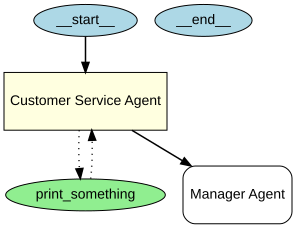

In [34]:
class ManagerEscalation(BaseModel):
    issue: str  # the issue being escalated
    reason: str  # the reason for escalation


@function_tool
def print_something():
    print("hello agent")


@function_tool
def create_ticket(issue: str):
    """Create a ticket for the escalated issue"""
    # Simulate ticket creation
    print(f"Ticket created for issue: {issue}")
    return f"Ticket created successfully ID {random.randint(10000, 99999)}"


manager_agent = Agent(
    name="Manager Agent",
    handoff_description="Handles Escalated Issues that requires managerial oversight",
    instructions="""
    you handle escalated customer issues that the initial customer service agent could not resolve.
    you will recieve the issue and the reason for escalation if the issue could not be resolved for the 
    customer create a ticket and inform the customer.
    """,
    tools=[create_ticket],
    model="gpt-4o-mini",
)


def on_manager_handoff(ctx: RunContextWrapper[None], input: ManagerEscalation):
    print("Escalating to the Manager Agent : \t", input.issue)
    print("Reason For Escalation : \t", input.reason)


customer_service_agent = Agent(
    name="Customer Service Agent",
    handoff_description="Handles initial customer inquiries and issues",
    instructions="""
    you are the first point of contact for customer inquiries.
    if you cannot resolve the issue, escalate it to the manager agent.
    """,
    model="gpt-4o-mini",
    tools=[print_something],
    handoffs=[
        handoff(
            manager_agent,
            input_type=ManagerEscalation,
            on_handoff=on_manager_handoff,
        ),
    ],
)

with trace("Customer Service Workflow"):
    result = await Runner.run(
        customer_service_agent, "I need a refund but the website is blank"
    )
    print(result.final_output)

draw_graph(customer_service_agent)
# draw_graph(manager_agent)